# Обучение без учителя. Методы K-Means & PCA

### 1. Установка PySpark & Spark

In [2]:
!pip install pyspark
!pip install -U -q PyDrive
!pip install install-jdk
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"

  Created wheel for install-jdk: filename=install_jdk-0.3.0-py3-none-any.whl size=3741 sha256=6d2bc48f40d4f55b982f05351f33b9202750ff9a28a7c335999e90a6c2fbccd4
  Stored in directory: c:\users\polina\appdata\local\pip\cache\wheels\6d\c1\df\0ced68ba61c8fd2dc97c5f8cc636ee8d8da444b23cce70c6f4
Successfully built install-jdk


### 2. Импорт библиотек

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import pyspark
from pyspark.sql import *
from pyspark.sql.types import *
from pyspark.sql.functions import *
from pyspark import SparkContext, SparkConf

### 3. Инициализация SparkContext

In [ ]:
sc = SparkContext()
spark = SparkSession.builder\
    .appName("StructuredNetworkWordCount")\
    .getOrCreate()

##### Датасет

Дан набор данных, содержащих информацию о [диагностике рака молочной железы](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic) . \
Выходные данные - характер опухоли (доброкачественная, злокачественная).\
Каждая опухоль описывается при помощи 30 вещественных атрибутов.

### 4. Загрузка данных

In [ ]:
from sklearn.datasets import load_breast_cancer
breast_cancer = load_breast_cancer()

In [ ]:
len(breast_cancer.data)

569

### 5. Преобразование данных

Так как датасет небольшой, воспользуемся pandas для преобразования данных. \
После получения pandas DataFrame, воспользуемся [Spark DataFrame](https://spark.apache.org/docs/latest/api/python/getting_started/quickstart_df.html#DataFrame-Creation)

In [ ]:
pd_df = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
df = spark.createDataFrame(pd_df)
df.show()

+-----------+------------+--------------+---------+---------------+----------------+--------------+-------------------+-------------+----------------------+------------+-------------+---------------+----------+----------------+-----------------+---------------+--------------------+--------------+-----------------------+------------+-------------+---------------+----------+----------------+-----------------+---------------+--------------------+--------------+-----------------------+
|mean radius|mean texture|mean perimeter|mean area|mean smoothness|mean compactness|mean concavity|mean concave points|mean symmetry|mean fractal dimension|radius error|texture error|perimeter error|area error|smoothness error|compactness error|concavity error|concave points error|symmetry error|fractal dimension error|worst radius|worst texture|worst perimeter|worst area|worst smoothness|worst compactness|worst concavity|worst concave points|worst symmetry|worst fractal dimension|
+-----------+------------+

In [ ]:
def map_to_nullable(spark, df, column_list, nullable=False):
    for struct_field in df.schema:
        if struct_field.name in column_list:
            struct_field.nullable = nullable
    df_mod = spark.createDataFrame(df.rdd, df.schema)
    return df_mod

df = map_to_nullable(spark, df, df.columns)
df = df.withColumn('features', array(df.columns))
vectors = df.rdd.map(lambda row: Vectors.dense(row.features))

df.printSchema()

root
 |-- mean radius: double (nullable = false)
 |-- mean texture: double (nullable = false)
 |-- mean perimeter: double (nullable = false)
 |-- mean area: double (nullable = false)
 |-- mean smoothness: double (nullable = false)
 |-- mean compactness: double (nullable = false)
 |-- mean concavity: double (nullable = false)
 |-- mean concave points: double (nullable = false)
 |-- mean symmetry: double (nullable = false)
 |-- mean fractal dimension: double (nullable = false)
 |-- radius error: double (nullable = false)
 |-- texture error: double (nullable = false)
 |-- perimeter error: double (nullable = false)
 |-- area error: double (nullable = false)
 |-- smoothness error: double (nullable = false)
 |-- compactness error: double (nullable = false)
 |-- concavity error: double (nullable = false)
 |-- concave points error: double (nullable = false)
 |-- symmetry error: double (nullable = false)
 |-- fractal dimension error: double (nullable = false)
 |-- worst radius: double (nullable

Построим 2 следующих датафрейма

* ```features``` - датафрейм, содержащий информацию о признаках опухоли;
* ```labels``` - бинарная серия с информацией о том, принадлежит ли соответствующий набор признаков злокачественной опухоли или нет. 


In [ ]:
from pyspark.ml.linalg import Vectors
features = spark.createDataFrame(vectors.map(Row), ["features"])
labels = pd.Series(breast_cancer.target)

In [ ]:
features.show()

+--------------------+
|            features|
+--------------------+
|[17.99,10.38,122....|
|[20.57,17.77,132....|
|[19.69,21.25,130....|
|[11.42,20.38,77.5...|
|[20.29,14.34,135....|
|[12.45,15.7,82.57...|
|[18.25,19.98,119....|
|[13.71,20.83,90.2...|
|[13.0,21.82,87.5,...|
|[12.46,24.04,83.9...|
|[16.02,23.24,102....|
|[15.78,17.89,103....|
|[19.17,24.8,132.4...|
|[15.85,23.95,103....|
|[13.73,22.61,93.6...|
|[14.54,27.54,96.7...|
|[14.68,20.13,94.7...|
|[16.13,20.68,108....|
|[19.81,22.15,130....|
|[13.54,14.36,87.4...|
+--------------------+
only showing top 20 rows



In [ ]:
labels.values

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

### 6. Бинарная классификация методом K-means 

Для решения задачи воспользуемся методом [K-means](https://spark.apache.org/docs/latest/ml-clustering.html) из пакета SparkML.
Так как количество классов равно двум, установите параметр ```k=2```.

Вычислим точность полученной K-means модели. Сравним выходные данные модели с выходными даннными исходного датасета.\
Изначально K-Means является алгоритмом кластеризации.\
Это означает, что он возвращает номера кластеров. Данные номера необязательно равны выходной переменной.\
Задача - понять, в какой кластер попали те или иные опухоли. И уже на основе этого оценивать accuracy метода.\

$accuracy = \frac {S} {N}$;\
где $S$ - количество опухолей, отнесённых к правильному классу;\
$N$ - общий размер датасета.

In [ ]:
# базовая модель
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

kmeans = KMeans(k=2, seed=1)
model = kmeans.fit(features)

predictions = model.transform(features)
predictions.show()

+--------------------+----------+
|            features|prediction|
+--------------------+----------+
|[17.99,10.38,122....|         1|
|[20.57,17.77,132....|         1|
|[19.69,21.25,130....|         1|
|[11.42,20.38,77.5...|         0|
|[20.29,14.34,135....|         1|
|[12.45,15.7,82.57...|         0|
|[18.25,19.98,119....|         1|
|[13.71,20.83,90.2...|         0|
|[13.0,21.82,87.5,...|         0|
|[12.46,24.04,83.9...|         0|
|[16.02,23.24,102....|         0|
|[15.78,17.89,103....|         1|
|[19.17,24.8,132.4...|         1|
|[15.85,23.95,103....|         0|
|[13.73,22.61,93.6...|         0|
|[14.54,27.54,96.7...|         0|
|[14.68,20.13,94.7...|         0|
|[16.13,20.68,108....|         1|
|[19.81,22.15,130....|         1|
|[13.54,14.36,87.4...|         0|
+--------------------+----------+
only showing top 20 rows



Кластер 1 -> признак 0\
Кластер 0 -> признак 1

In [ ]:
predictions = np.array([rows[i].prediction for i in range(len(rows))])

In [ ]:
# функция подсчета точности модели
def getAccuracy(modelRows, datasetLabels):
  coincidencesCount = 0;
  for i, label in enumerate(datasetLabels):
      if label != modelRows[i].prediction:
          coincidencesCount = coincidencesCount + 1;

  labelsLength = len(datasetLabels);
  print(coincidencesCount, '/', labelsLength)

  return coincidencesCount/labelsLength;

In [ ]:
# подсчет точности базовой модели
rows = predictions.select('prediction').collect();
baseAccuracy = getAccuracy(rows, labels)
print('Точность базовой модели: ', baseAccuracy * 100, '%')

83 / 569
Точность базовой модели:  14.586994727592268 %


In [ ]:
# модель с улучшенной точностью

# seed: 1 -> 100
# distanceMeasure: 'euclidean' (default) -> 'cosine'

kmeans = KMeans(k=2, seed=100, distanceMeasure='cosine')
model = kmeans.fit(features)

updPredictions = model.transform(features)
updPredictions.show()

+--------------------+----------+
|            features|prediction|
+--------------------+----------+
|[17.99,10.38,122....|         1|
|[20.57,17.77,132....|         1|
|[19.69,21.25,130....|         1|
|[11.42,20.38,77.5...|         1|
|[20.29,14.34,135....|         0|
|[12.45,15.7,82.57...|         1|
|[18.25,19.98,119....|         1|
|[13.71,20.83,90.2...|         1|
|[13.0,21.82,87.5,...|         1|
|[12.46,24.04,83.9...|         1|
|[16.02,23.24,102....|         1|
|[15.78,17.89,103....|         1|
|[19.17,24.8,132.4...|         0|
|[15.85,23.95,103....|         0|
|[13.73,22.61,93.6...|         0|
|[14.54,27.54,96.7...|         1|
|[14.68,20.13,94.7...|         1|
|[16.13,20.68,108....|         1|
|[19.81,22.15,130....|         1|
|[13.54,14.36,87.4...|         0|
+--------------------+----------+
only showing top 20 rows



In [ ]:
# подсчет точности улучшенной модели
updRows = updPredictions.select('prediction').collect();
updAccuracy = getAccuracy(updRows, labels)
print('Точность улучшенной модели: ', updAccuracy * 100, '%')

509 / 569
Точность улучшенной модели:  89.45518453427064 %


In [ ]:
# изменение точности
print(baseAccuracy * 100, '% ->', updAccuracy * 100, '%')

85.41300527240774 % -> 89.45518453427064 %


### 7. Понижение размерности методом PCA

Проведем понижение размерности при [помощи метода главных компонент](http://infolab.stanford.edu/~ullman/mmds/ch11.pdf).\
Более подробное изложение можно найти [по ссылке](https://arxiv.org/pdf/1404.1100.pdf).\
Данный метод также доступен в пакете [MLlib](https://spark.apache.org/docs/latest/ml-features.html#pca). 

Установим параметр ```k = 2 ```, понизив размерность входного пространства в **15** раз.


In [ ]:
from pyspark.ml.feature import PCA
from pyspark.ml.linalg import Vectors

pca = PCA(k=2, inputCol="features", outputCol="pcaFeatures")
model = pca.fit(features)

pcaFeatures = model.transform(features).select("pcaFeatures")
pcaFeatures.show(truncate=False)

+-----------------------------------------+
|pcaFeatures                              |
+-----------------------------------------+
|[-2260.0138862925405,-187.96030122263687]|
|[-2368.9937557820535,121.58742425815493] |
|[-2095.66520154786,145.11398565870115]   |
|[-692.6905100570506,38.57692259208172]   |
|[-2030.2124927427058,295.29798399279287] |
|[-888.2800535760758,26.079796157025683]  |
|[-1921.0822124748443,58.80757247309935]  |
|[-1074.7813350047963,31.771227808469586] |
|[-908.5784781618829,63.83075279044626]   |
|[-861.578449407568,40.57073549705317]    |
|[-1404.5591306499468,88.23218257736238]  |
|[-1524.2324408687816,-3.2630573167779446]|
|[-1734.3856477464153,273.1626781511456]  |
|[-1162.9140032230355,217.63481808344625] |
|[-903.4301030498832,135.61517666084788]  |
|[-1155.8759954206846,76.80889383742178]  |
|[-1335.7294321308066,-2.4684005450354807]|
|[-1547.2640922523085,3.8056759725745044] |
|[-2714.964765181215,-164.37610864258824] |
|[-908.2502671870876,118.2164200

### 8. Бинарная классификация метдом K-means на данных меньшей размерности

Обучим модель KMeans также как в задании 2, но уже на признаках меньшей размерности. 
Оценим результат классификации.
 
Выведем точечную диаграмму, отображающую зависимость первого признака от второго. Точки на диаграмме должны быть покрашены в зависимости от принадлежности тому или иному классу.

In [ ]:
# базовая PCA модель
kmeans = KMeans(featuresCol="pcaFeatures", k=2, seed=1)
model = kmeans.fit(pcaFeatures)

pcaPredictions = model.transform(pcaFeatures)
pcaPredictions.show()

+--------------------+----------+
|         pcaFeatures|prediction|
+--------------------+----------+
|[-2260.0138862925...|         1|
|[-2368.9937557820...|         1|
|[-2095.6652015478...|         1|
|[-692.69051005705...|         0|
|[-2030.2124927427...|         1|
|[-888.28005357607...|         0|
|[-1921.0822124748...|         1|
|[-1074.7813350047...|         0|
|[-908.57847816188...|         0|
|[-861.57844940756...|         0|
|[-1404.5591306499...|         0|
|[-1524.2324408687...|         1|
|[-1734.3856477464...|         1|
|[-1162.9140032230...|         0|
|[-903.43010304988...|         0|
|[-1155.8759954206...|         0|
|[-1335.7294321308...|         0|
|[-1547.2640922523...|         1|
|[-2714.9647651812...|         1|
|[-908.25026718708...|         0|
+--------------------+----------+
only showing top 20 rows



In [ ]:
# подсчет точности базовой PCA модели
pcaRows = pcaPredictions.select('prediction').collect();
basePcaAccuracy = getAccuracy(pcaRows, labels)
print('Точность PCA модели: ', basePcaAccuracy * 100, '%')

486 / 569
Точность PCA модели:  85.41300527240774 %


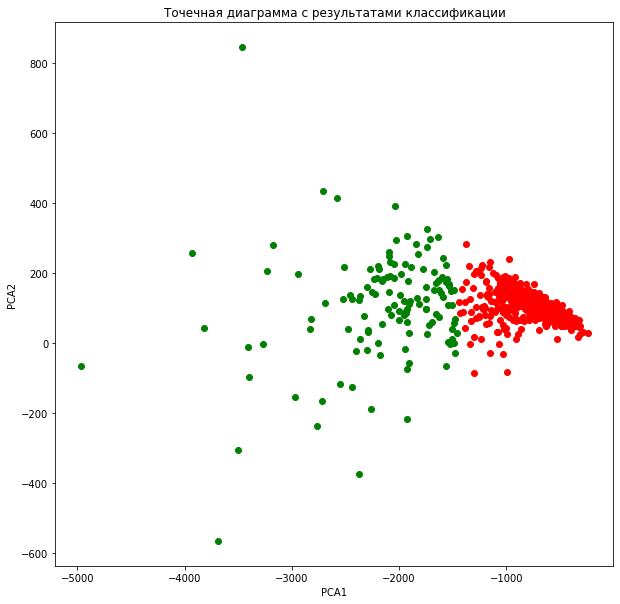

In [ ]:
from sklearn.manifold import TSNE

rows = pcaPredictions.collect();
plt.figure(figsize=(10,10))

for row in rows:
  color = 'green' if row.prediction == 1 else 'red';
  plt.plot(row.pcaFeatures[0], row.pcaFeatures[1], 'o', color=color);

plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('Точечная диаграмма с результатами классификации')
plt.show()

In [ ]:
# PCA модель с улучшенной точностью

# seed: 1 -> 10
# distanceMeasure: 'euclidean' (default) -> 'cosine'
# maxIter: 20 (default) -> 10
# initSteps: 2 (default) -> 100

kmeans = KMeans(featuresCol="pcaFeatures", k=2, seed=10, distanceMeasure='cosine', maxIter=10, initSteps=100)
model = kmeans.fit(pcaFeatures)

updPcaPredictions = model.transform(pcaFeatures)
updPcaPredictions.show()

+--------------------+----------+
|         pcaFeatures|prediction|
+--------------------+----------+
|[-2260.0138862925...|         1|
|[-2368.9937557820...|         1|
|[-2095.6652015478...|         1|
|[-692.69051005705...|         1|
|[-2030.2124927427...|         0|
|[-888.28005357607...|         1|
|[-1921.0822124748...|         1|
|[-1074.7813350047...|         1|
|[-908.57847816188...|         1|
|[-861.57844940756...|         1|
|[-1404.5591306499...|         1|
|[-1524.2324408687...|         1|
|[-1734.3856477464...|         0|
|[-1162.9140032230...|         0|
|[-903.43010304988...|         0|
|[-1155.8759954206...|         1|
|[-1335.7294321308...|         1|
|[-1547.2640922523...|         1|
|[-2714.9647651812...|         1|
|[-908.25026718708...|         0|
+--------------------+----------+
only showing top 20 rows



In [ ]:
# подсчет точности улучшенной PCA модели
updPcaRows = updPcaPredictions.select('prediction').collect();
updPcaAccuracy = getAccuracy(updPcaRows, labels)
print('Точность улучшенной PCA модели: ', updPcaAccuracy * 100, '%')

490 / 569
Точность улучшенной PCA модели:  86.11599297012302 %


In [ ]:
# изменение точности
print(basePcaAccuracy * 100, '% ->', updPcaAccuracy * 100, '%')

85.41300527240774 % -> 86.11599297012302 %


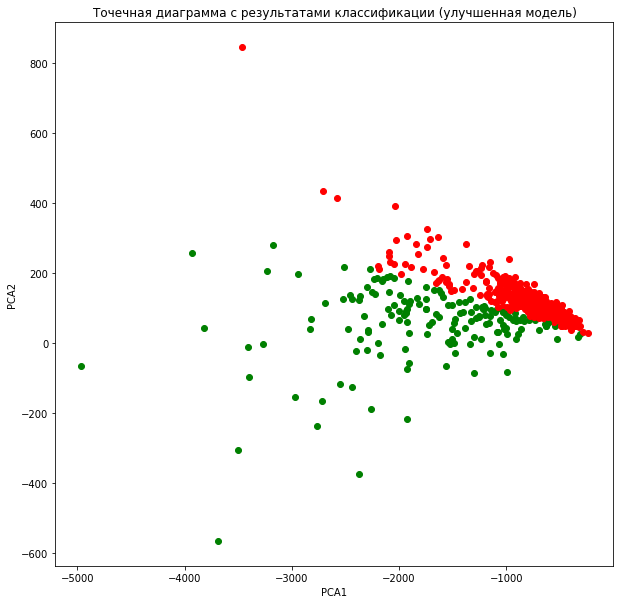

In [ ]:
rows = updPcaPredictions.collect();
plt.figure(figsize=(10,10))

for row in rows:
  color = 'green' if row.prediction == 1 else 'red';
  plt.plot(row.pcaFeatures[0], row.pcaFeatures[1], 'o', color=color);

plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('Точечная диаграмма с результатами классификации (улучшенная модель)')
plt.show()